In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten ,Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping , ModelCheckpoint
import tensorflow_datasets as tfds
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from tensorflow.keras.regularizers import l2
from tensorflow.keras import layers , models

In [3]:
(train,test),ds_info = tfds.load('food101',as_supervised=True,with_info=True,split=['train','validation'])

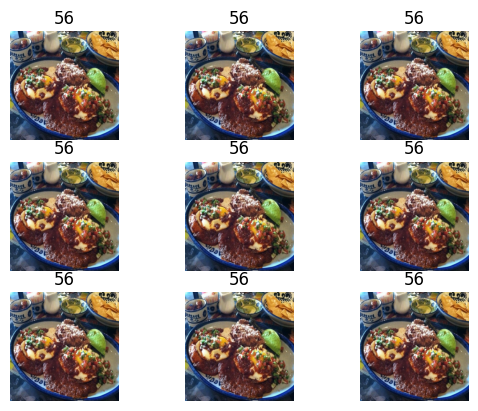

In [4]:
for image, label in train.take(1): #.take(1) to take one sample from the dataset(only one batch of trainning dataset)
    for i in range(9):
         plt.subplot(3,3,i+1)
         plt.imshow(image.numpy())
         plt.title(label.numpy())
         plt.axis('off')
plt.show()
    

In [5]:
IMG_SIZE = (224,224) # we need to resize the images to a fixed size for the model to be able to process them and also to reduce the computational cost of the model we will use 224x224 as the input size for the model because it is a common size for image classification tasks and it is also the size used by the pre-trained models that we will use later in the session

In [6]:
def preprocess(image,label):
    image = tf.image.resize(image,IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0 # normalization what is the purpose of this step and why we divide by 255.0 tensorflow image is in the range of 0-255 and we want to scale it to the range of 0-1 for better performance of the model
    return image,label

In [7]:
train = train.map(preprocess)# we need to apply the preprocess function to all the images in the train and test datasets to resize and normalize them before feeding them to the model
test = test.map(preprocess) # we need to apply the preprocess function to all the images in the train and test datasets to resize and normalize them before feeding them to the model

In [8]:
data_augmentation = Sequential([
    layers.RandomFlip('horizontal'), # we will randomly flip the images horizontally to increase the diversity of the training data and help the model generalize better
    layers.RandomRotation(0.15), # we will randomly rotate the images by 15 degrees to increase the diversity of the training data and help the model generalize better
    layers.RandomZoom(0.2), # we will randomly zoom the images by 20% to increase the diversity of the training data and help the model generalize better
    layers.RandomContrast(0.2) # we will randomly change the contrast of the images by 20% to increase the diversity of the training data and help the model generalize better  
])

In [9]:
def conv_block(x,filters): 
    x = layers.Conv2D(filters,(3,3),activation='relu',padding='same')(x) # we will use 3x3 convolutional filters with ReLU activation function and same padding to preserve the spatial dimensions of the input
    x = layers.BatchNormalization()(x) # we will use batch normalization to normalize the activations of the convolutional layers and help the model converge faster and also to reduce the overfitting    
    x = layers.MaxPooling2D(2)(x) # we will use max pooling with a pool size of 2 to reduce the spatial dimensions of the input by half and also to reduce the computational cost of the model
    return x

In [11]:
inputs = layers.Input(shape=(224,224,3)) # we will use an input layer with the shape of the preprocessed images (224,224,3) where 3 is the number of color channels (RGB)
x = data_augmentation(inputs) # we will apply the data augmentation to the input images to increase the diversity of the training data and help the model generalize better
x = conv_block(x,32) # we will use a convolutional block with 32 filters to extract features from the input images
x = conv_block(x,64) # we will use a convolutional block with 64 filters to extract more complex features from the input images
x = conv_block(x,128) # we will use a convolutional block with 128 filters to extract even more complex features from
x = conv_block(x,256) # we will use a convolutional block with 256 filters to extract even more complex features from the input images

x - layers.Dense(256, activation = 'relu')(x)
x = layers.Dropout(0.5)(x) # we will use dropout with a rate of 0.5 to randomly drop 50% of the neurons in the fully connected layer to reduce overfitting
outputs = layers.Dense(101, activation = 'softmax')(x) # we will use a fully connected layer with 101 neurons and softmax activation function to output the probabilities of each class

model = models.Model(inputs,outputs) # we will create a model using the functional API of Keras by specifying the input and output layers
model.summary() # we will print the summary of the model to see the architecture and the number of parameters in each layer

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 14, 14, 101)    │        25,957 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 416,293 (1.59 MB)

 Trainable params: 415,333 (1.58 MB)

 Non-trainable params: 960 (3.75 KB)

In [14]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy']) # we will compile the model using the Adam optimizer with a learning rate of 0.001 and sparse categorical crossentropy loss function because we have more than 2 classes and the labels are integers

In [15]:
history = model.fit(train.batch(32), validation_data=test.batch(32), epochs=5) # we will train the model for 20 epochs using a batch size of 32 and we will also use the test dataset as the validation data to monitor the performance of the model on unseen data during training

Epoch 1/5


ValueError: Argument `output` must have rank (ndim) `target.ndim - 1`. Received: target.shape=(None,), output.shape=(None, 14, 14, 101)